In [1]:
# Phase 1: Setup and Data Loading

# install libraries
!pip install pandas numpy scikit-learn matplotlib seaborn

# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# mount drive
from google.colab import drive
drive.mount('/content/drive')

# file path (change if your file is inside a folder)
file_path = '/content/drive/MyDrive/cyberbullying_tweets.csv'

# load dataset
df = pd.read_csv(file_path)

# basic checks
print("Dataset shape:", df.shape)

# view data
df.head()

Mounted at /content/drive
Dataset shape: (47692, 2)


,tweet_text,cyberbullying_type
0,"In other words #katandandre, your food was cra...",not_cyberbullying
1,Why is #aussietv so white? #MKR #theblock #ImA...,not_cyberbullying
2,@XochitlSuckkks a classy whore? Or more red ve...,not_cyberbullying
3,"@Jason_Gio meh. :P thanks for the heads up, b...",not_cyberbullying
4,@RudhoeEnglish This is an ISIS account pretend...,not_cyberbullying


In [2]:
# check columns
print("Columns:", df.columns)

# check missing values
print(df.isnull().sum())

# check class distribution
print(df['cyberbullying_type'].value_counts())

Columns: Index(['tweet_text', 'cyberbullying_type'], dtype='object')
tweet_text            0
cyberbullying_type    0
dtype: int64
cyberbullying_type
religion               7998
age                    7992
gender                 7973
ethnicity              7961
not_cyberbullying      7945
other_cyberbullying    7823
Name: count, dtype: int64


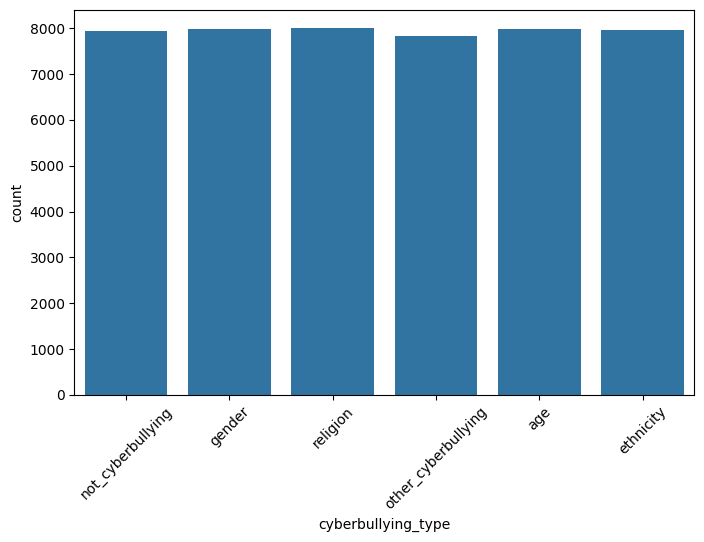

In [3]:
plt.figure(figsize=(8,5))
sns.countplot(x='cyberbullying_type', data=df)
plt.xticks(rotation=45)
plt.show()

Data Preprocessing

In [4]:
# Phase 2: Data Cleaning and Preprocessing

import re
from sklearn.preprocessing import LabelEncoder

# make a copy of original data
data = df.copy()

# convert text to lowercase
data['tweet_text'] = data['tweet_text'].astype(str).str.lower()

# function to clean text
def clean_text(text):
    text = re.sub(r"http\S+", " ", text)          # remove links
    text = re.sub(r"@\w+", " ", text)             # remove mentions
    text = re.sub(r"#\w+", " ", text)             # remove hashtags
    text = re.sub(r"[^a-z\s]", " ", text)         # keep only letters
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

# apply cleaning
data['clean_text'] = data['tweet_text'].apply(clean_text)

# remove empty rows after cleaning
data = data[data['clean_text'].str.strip() != ""]

# reset index
data = data.reset_index(drop=True)

# encode labels
encoder = LabelEncoder()
data['label'] = encoder.fit_transform(data['cyberbullying_type'])

# check mapping
label_map = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Label mapping:")
print(label_map)

# check processed data
data[['clean_text', 'label']].head()

Label mapping:
{'age': np.int64(0), 'ethnicity': np.int64(1), 'gender': np.int64(2), 'not_cyberbullying': np.int64(3), 'other_cyberbullying': np.int64(4), 'religion': np.int64(5)}


,clean_text,label
0,in other words your food was crapilicious,3
1,why is so white,3
2,a classy whore or more red velvet cupcakes,3
3,meh p thanks for the heads up but not too conc...,3
4,this is an isis account pretending to be a kur...,3


In [5]:
# check data size after cleaning
print("New shape:", data.shape)

# check class balance again
print(data['label'].value_counts())

New shape: (47303, 4)
label
5    7998
0    7992
1    7955
2    7935
3    7815
4    7608
Name: count, dtype: int64


train-test split and baseline model

In [6]:
# Phase 3: Train-Test Split and Baseline Model

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# define input and output
X = data['clean_text']
y = data['label']

# split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# convert text into numeric features
vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# train baseline model
baseline_model = LogisticRegression(max_iter=200)
baseline_model.fit(X_train_vec, y_train)

print("Baseline model training completed")

Training size: (37842,)
Testing size: (9461,)
Baseline model training completed


In [7]:
# quick prediction check
sample_preds = baseline_model.predict(X_test_vec[:5])
print("Sample predictions:", sample_preds)

Sample predictions: [4 5 5 5 5]


evaluation of baseline model

In [8]:
# Phase 4: Evaluation of Baseline Model

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# predictions on test data
y_pred = baseline_model.predict(X_test_vec)

# accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n")
print(cm)

Accuracy: 0.8179896416869252

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97      1598
           1       0.97      0.97      0.97      1591
           2       0.89      0.82      0.85      1587
           3       0.57      0.54      0.55      1563
           4       0.58      0.64      0.61      1522
           5       0.94      0.94      0.94      1600

    accuracy                           0.82      9461
   macro avg       0.82      0.82      0.82      9461
weighted avg       0.82      0.82      0.82      9461


Confusion Matrix:

[[1566    2    1   20    8    1]
 [   2 1545    6   12   23    3]
 [   4    7 1294  150  127    5]
 [  46   14   70  844  533   56]
 [  18   19   72  409  979   25]
 [   0    2    7   58   22 1511]]


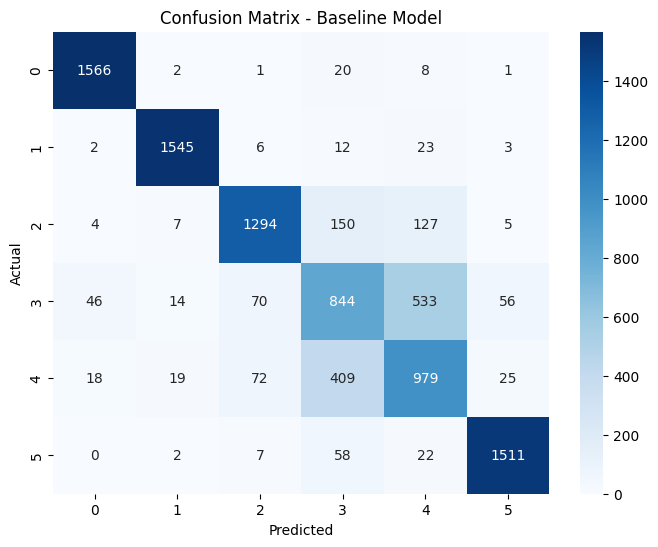

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Baseline Model")
plt.show()